In [ ]:
from experiments.replications import (
    run_replications,
    summarize_ci,
    compare_policies,
    labeled_policy_grid,
)
from policy.queue.fifo import FIFOQueuePolicy
from policy.queue.lowest_soc_diff import LowestSoCDiffQueuePolicy
from policy.queue.closest_power_match import ClosestPowerMatchQueuePolicy
from policy.power.proportional import ProportionalPower
from policy.power.static import StaticPower
import pandas as pd


In [4]:
# --- inputs ---
# mx_wait is filled from the first FIFO run, then applied to other queue rules.
mx_wait = None

queue_policies = [
    FIFOQueuePolicy(),
    LowestSoCDiffQueuePolicy(),
]
#    ClosestPowerMatchQueuePolicy(),
#]
queue_names = ["FIFO", "LSoCD"] #, "L_SoC_D", "P_Match"]

# Parallel list: one name per power-policy instance (same idea as queue_names).
# One power policy → scenario labels stay queue names (FIFO, L_SoC_D, ...).
# Several power policies and several queue policies → FIFO_Prop, FIFO_Static, ...
power_policies = [
#    StaticPower(),
    ProportionalPower()
    # StaticPower(),  # equal module split; leftovers by unmet p_req
]
power_names = ["Prop"]
# power_names = ["Prop", "Static"]  # with both: FIFO_Prop, FIFO_Static, ...

scenario = {
    "n_piles": 2,
    "n_dispensers": 2,
    "n_modules": 6,
    "p_module": 25,
    "queue_capacity": 100,
    "mean_interarrival": 30,
}

n_reps = 30
confidence = 0.95
seed0 = 0

grid = labeled_policy_grid(
    queue_policies, queue_names, power_policies, power_names
)

# --- run ---
reps = {}
summaries = {}
mean_cols = {}

for label, q_pol, p_pol, q_name, _p_name in grid:
    if q_name != "FIFO" and mx_wait:
        q_pol.max_wait = mx_wait * 0.75
    r = run_replications(
        scenario={**scenario, "queue_policy": q_pol, "power_policy": p_pol},
        n_reps=n_reps,
        seed0=seed0,
    )
    s = summarize_ci(r, confidence=confidence)
    if q_name == "FIFO" and mx_wait is None:
        mx_wait = s.loc["max wait time", "mean"]

    reps[label] = r
    summaries[label] = s
    mean_cols[f"{label}_mean"] = s["mean"]

# paired CRN comparisons (same seeds)
signs, pair_details = compare_policies(reps, confidence=confidence)


In [6]:
pd.DataFrame(mean_cols)

,FIFO_mean,LSoCD_mean
metric,,
finished EVs,46.366667,46.366667
dropped EVs,0.000000,0.000000
total energy delivered (kWh),4052.697557,4053.182928
average L,1.818281,1.818290
average Q,0.108688,0.110627
avg wait time,3.144988,3.175761
max wait time,40.762366,42.070425
avg charge time,51.454764,51.384621
avg sys time,54.599752,54.560381


In [4]:
signs  # -1: first policy lower; 0: n.s.; 1: second policy lower


,FIFO|L_SoC_D,FIFO|P_Match,L_SoC_D|P_Match
metric,,,
finished EVs,0,-1,-1
dropped EVs,0,0,0
total energy delivered (kWh),0,-1,-1
average L,1,1,1
average Q,1,1,1
avg wait time,1,1,0
max wait time,-1,0,1
avg sys time,1,1,0
util_rho_sim,0,0,0


In [7]:
pair_details['FIFO']['P_Match']

,FIFO,P_Match,significant,ci_low,ci_high
metric,,,,,
finished EVs,58.900000,61.566667,True,-3.046454,-2.286879
dropped EVs,0.000000,0.000000,False,0.000000,0.000000
total energy delivered (kWh),3536.009413,3667.642117,True,-151.032163,-112.233244
average L,19.944063,18.539500,True,1.218671,1.590455
average Q,17.980722,16.575820,True,1.218943,1.590862
avg wait time,257.871254,235.761839,True,17.762002,26.456827
max wait time,521.452072,520.562538,False,-10.250398,12.029466
avg sys time,305.057246,280.959963,True,19.622168,28.572398
util_rho_sim,0.981670,0.981840,False,-0.000402,0.000063


In [7]:
import numpy as np
from env.charging_env import ChargingStationEnv
from policy.queue.fifo import FIFOQueuePolicy
from policy.power.proportional import ProportionalPower

env = ChargingStationEnv(
    n_piles=1,
    n_dispensers=2,
    n_modules=6,
    p_module=25,
    power_policy=ProportionalPower(),
    queue_capacity=100,
    mean_interarrival=60.0,
)

obs, info = env.reset(seed=42)
done = False
rng = np.random.default_rng(1)
policy = FIFOQueuePolicy()
total_reward = 0.0

while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, reward, done, _, info = env.step(pile_id, ev=ev)
    total_reward += reward

print(f"Finished EVs: {len(env.engine.metrics.finished_evs)}")
print(f"Dropped EVs: {len(env.engine.metrics.dropped_evs)}")
print(f"Avg L: {env.engine.metrics.average_L():.3f}")
print(f"Avg Q: {env.engine.metrics.average_Q():.3f}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time: {env.engine.current_time:.1f}")


Finished EVs: 22
Dropped EVs: 0
Avg L: 0.916
Avg Q: 0.153
Total reward: -220.335
Sim time: 1440.0


In [8]:
from metrics.validate import validate_episode, report_queueing_laws

summary = env.engine.metrics.queueing_summary(env.engine.current_time)
waits, services, sojourns = env.engine.metrics.finished_time_arrays()
rep_val = validate_episode(env, verbose=True)
reo_q = report_queueing_laws(env, verbose=True)


=== Episode validation ===
  arrived=22, finished=22, dropped=0, queued=0, plugged=0
  [PASS] Finished: s_current ~= s_f: ok for all finished EVs
  [PASS] Finished: energy_received ~= c_b*(s_f-s_i)/HR2MIN: ok for all finished EVs
  [PASS] Finished: energy_received ~= energy_received_2: ok for all finished EVs
  [PASS] Finished: departure_time >= service_start_time >= arrival_time: ok for all finished EVs
  [PASS] Finished: pile_tracker / dispenser_id_tracker set: ok for all finished EVs
  [PASS] Finished: p_act <= p_req in charge_trace: ok for all finished EVs
  [PASS] Dropped: never got service_start_time / empty charge_trace: ok for all dropped EVs
  [PASS] arrived = finished + dropped + queued + plugged: 22 vs 22+0+0+0=22

=== Queueing laws ===
  T=1440.0 min, finished=22, c=2 servers
  lambda_eff=0.015278 /min
  E[W]=59.9298 min, E[W_q]=10.0152 min, E[S]=49.9146 min
  Little L = lambda_eff * W :  theory=0.9156  sim=0.9156  |diff|=0.0000
  Little Q = lambda_eff * W_q:  theory=0.153

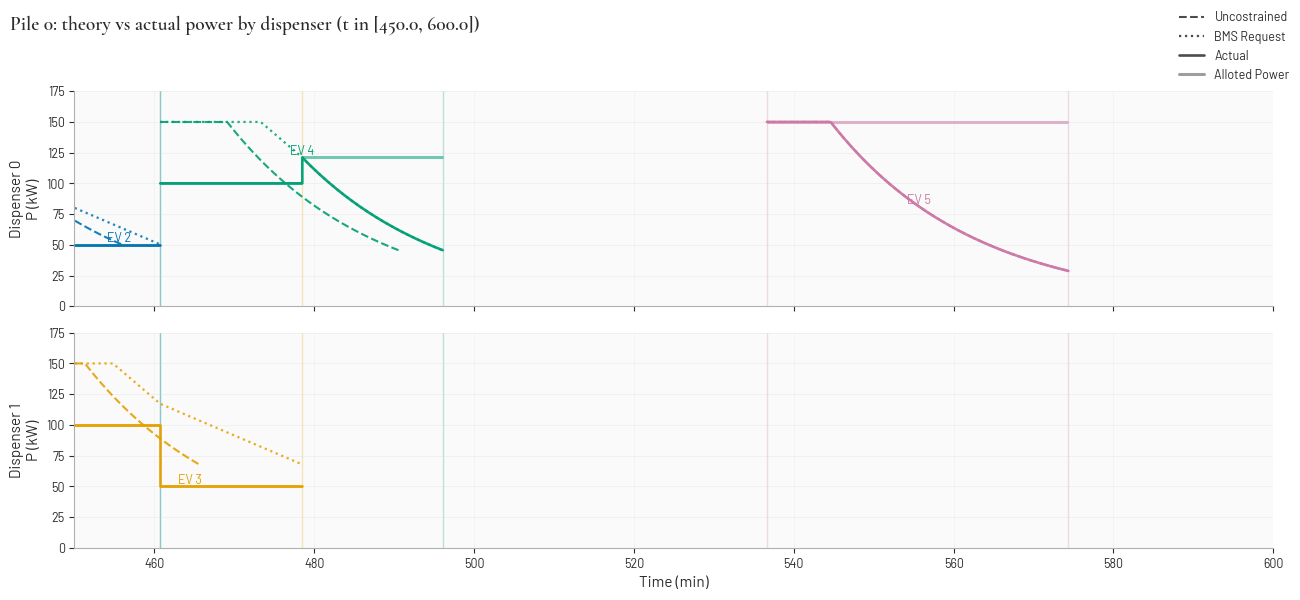

In [14]:
from visualization.pile_power import plot_pile_dispenser_power
import matplotlib.pyplot as plt

fig = plot_pile_dispenser_power(
    env, 0,
    t_start = 450,
    t_end=600,
    show_theory=True,      # default
    show_sim_bms=True,     # optional overlay
    show_actual=True,
    show_legend=True,
    label_theory="Uncostrained", # Power if this EV always got its full BMS request
    label_sim_bms="BMS Request",          # Max power the battery would accept at that SoC
    label_actual="Actual",       # Power the pile delivered
    label_charge_steps="Alloted Power", # Allotted power — module share held between redistributions.
    show_charge_change_lines=True,   # horizontal p_act plateaus between trace samples
    show_charge_change_vlines=False,
    show_trace_labels=False,          # P, t, s, n_modules at each charge_trace point
    title=None,              # default template with pile_id / window
    show_event_lines=True,
    event_line_alpha=0.25,
    show_ev_ids=True,
)
fig

Plotting EV 10 (pile 0, dispenser 1), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 11 (pile 0, dispenser 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 12 (pile 0, dispenser 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 13 (pile 0, dispenser 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 14 (pile 0, dispenser 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3


[<Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>]

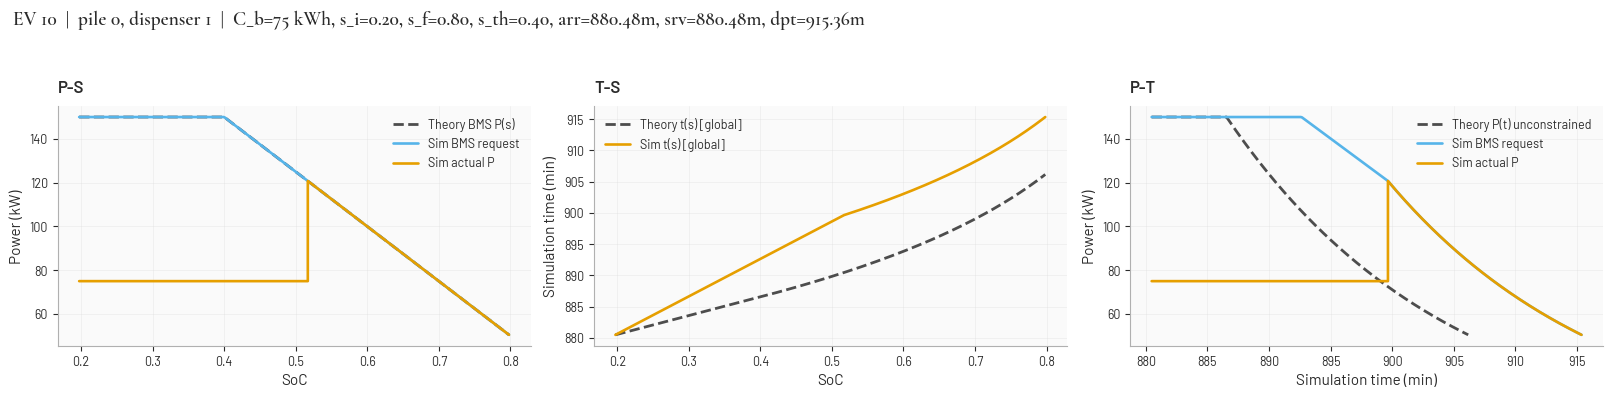

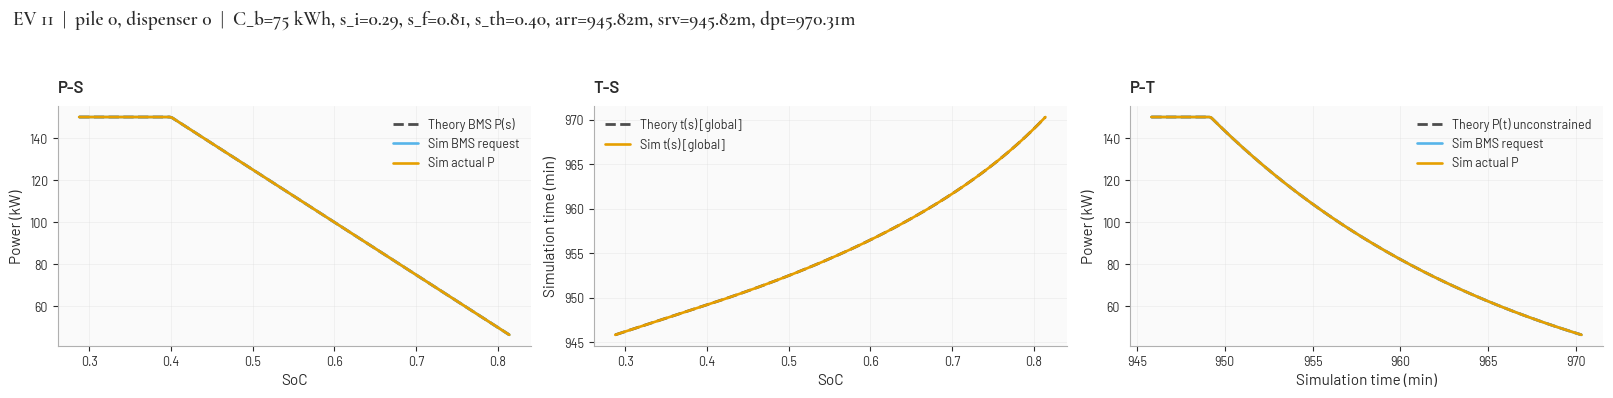

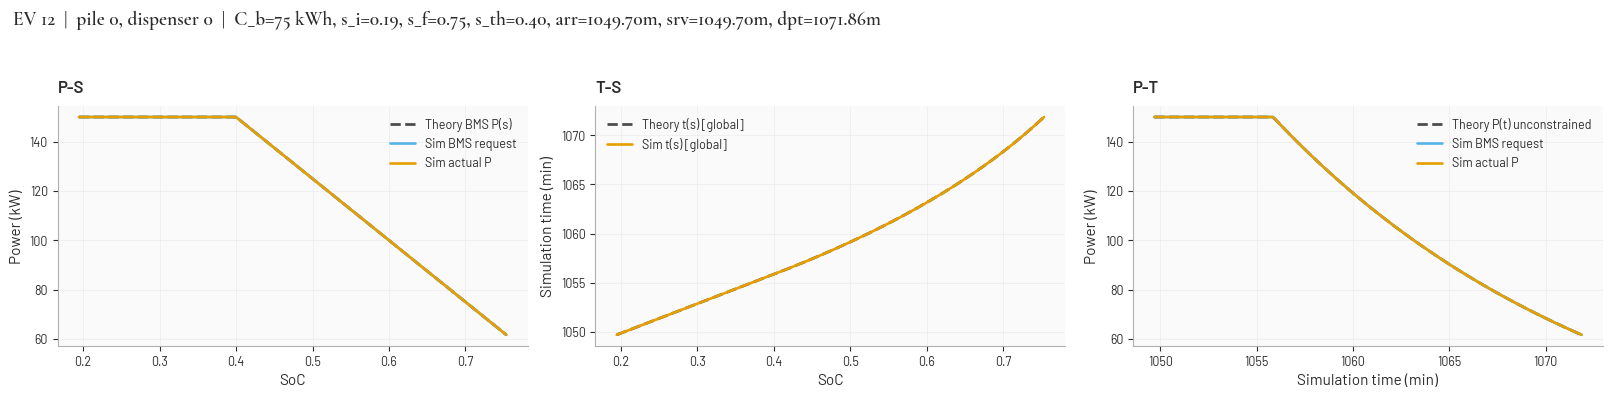

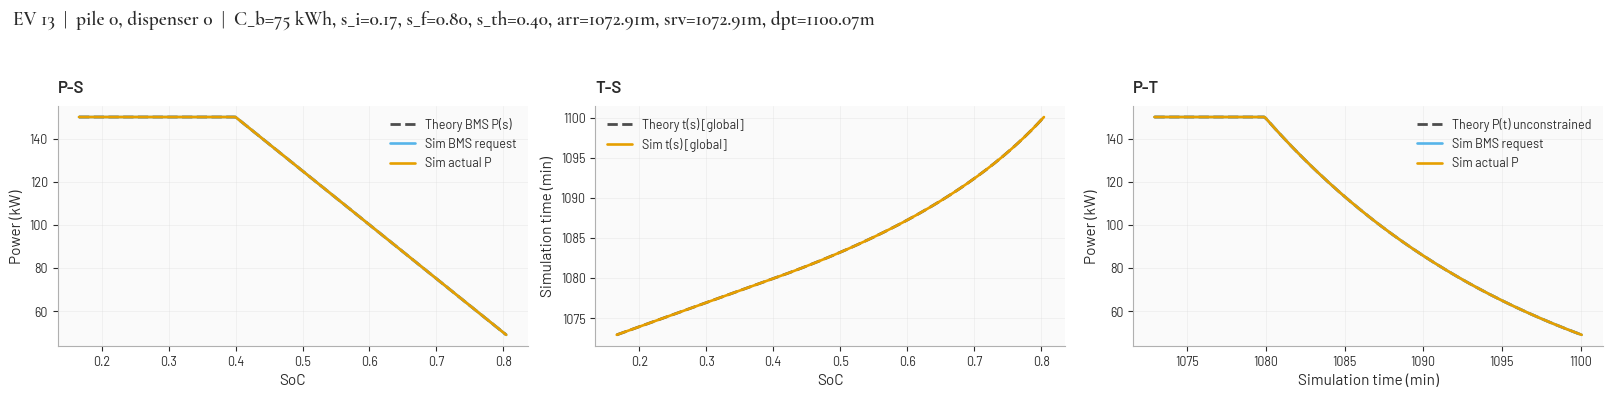

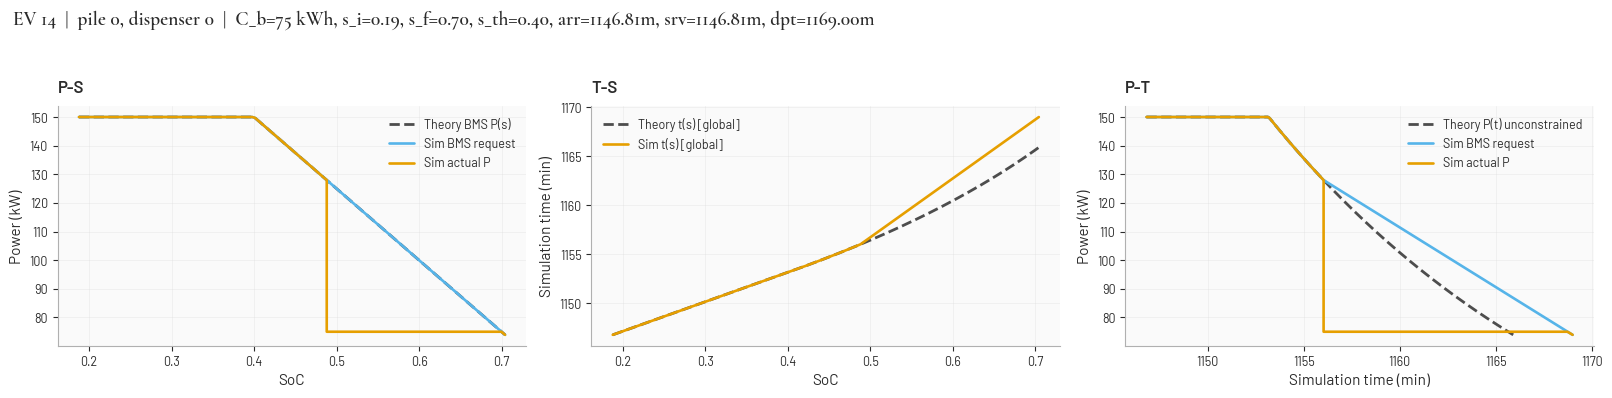

In [15]:
from visualization.ev_curves import plot_ev_theory_vs_sim
import matplotlib.pyplot as plt

figs = plot_ev_theory_vs_sim(
    env,
    ev_ids=[_ + 10 for _ in range(5)],
    charts=["P-S", "T-S", "P-T"],
    show_theory=True,
    show_sim_bms=True,
    show_sim_actual=True,
    show_recorded_samples=False,
    label_theory=None,       # defaults per chart if None
    label_sim_bms=None,
    label_sim_actual=None,   # on T-S → "Sim t(s) [global]"
    label_recorded=None,
)
figs
